# Task 2: Biomaker Embedding

This task is about giving biological meaning to the biomarkers (glycans) we previously discovered by embedding them (i.e. converting each glycan into a numerical representation) into a space that reflects their biochemical, functional, and clinical relationships (i.e. such that similar glycans are placed close together in the embedding space based on these features).

In this part, we will:
- Learn a meaningful embedding space that captures relationships between glycans based on structure, origin, tissue, disease, and protein interactions.
- Validate the embedding by using the N-glycans (known structures) as a ground-truth set
- Embed our discovered glycans into this space and assess their closeness to other structures to draw conclusions as to their nature.

In [1]:
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt
import time

# Machine Learning methods
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# Glycowork
from glycowork.motif.processing import min_process_glycans

# Personal helpers
from helpers_TASK2 import *

In [2]:
# Load the data
glycan_list = pd.read_csv("./data/glycan_embedding/glycan_list.csv")
df_glycan = pd.read_pickle("./data/glycan_embedding/df_glycan.pkl")
glycan_binding = pd.read_pickle("./data/glycan_embedding/glycan_binding.pkl")
N_glycans_df = pd.read_pickle("./data/glycan_embedding/N_glycans_df.pkl")

# Print the shape of each dataset
print(f"Shape of Glycan List (our discovered molecules): {glycan_list.shape}")
print(f"Shape of Glycan Dataset (sequences, species, tissue, disease): {df_glycan.shape}")
print(f"Shape of Protein-Glycan binding interactions Dataset: {glycan_binding.shape}")
print(f"Shape of N-glycans Dataset (N-gylcans sequences for control representation): {N_glycans_df.shape}")

Shape of Glycan List (our discovered molecules): (5, 4)
Shape of Glycan Dataset (sequences, species, tissue, disease): (50589, 23)
Shape of Protein-Glycan binding interactions Dataset: (1465, 2745)
Shape of N-glycans Dataset (N-gylcans sequences for control representation): (48, 24)


In [3]:
# Missing Values
print(f"Glycan List:\n{glycan_list.isna().sum()}\n")
print(f"Glycan DF:\n{df_glycan.isna().sum()}\n")
print(f"Glycan Binding:\n{glycan_binding.isna().sum()}\n")
print(f"N-Glycans:\n{N_glycans_df.isna().sum()}")

Glycan List:
glycan            0
Composition       0
tissue_species    0
tissue_sample     0
dtype: int64

Glycan DF:
glycan                     0
Species                    0
Genus                      0
Family                     0
Order                      0
Class                      0
Phylum                     0
Kingdom                    0
Domain                     0
ref                        0
glytoucan_id           15573
glycan_type            23628
disease_association        0
disease_id                 0
disease_sample             0
disease_direction          0
disease_ref                0
disease_species            0
tissue_sample              0
tissue_id                  0
tissue_ref                 0
tissue_species             0
Composition                0
dtype: int64

Glycan Binding:
3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3)Gal4S                                                                  1461
3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S        

## Part 1: Learn a Glycan Embedding Space

In part 1 of our analysis, we will build a feature space that places glycans near each other if they:
- Have similar sequences or compositions
- Come from similar species or tissues
- Are involved in the same diseases
- Bind to the same proteins

To do this, we will use machine learning to learn and validate the embedding, starting with simpler, interpretable models and eventually scaling-up to more complex architectures.

### Part 1A: Build Feature Matrix for each Glycan

For all gylcans in `df_glycan` and `glycan_list`, we will extract the following features:
- Sequence Proximity: we will investigate ways to define proximity between two sequences of glycans.
- Composition
- Species and Tissue

In [4]:
# Load df_glycan as is done in glycowork
df_glycan2 = copy.deepcopy(df_glycan)
df_glycan2.set_index("glycan", inplace = True)
df_glycan2.head(1).style.set_properties(**{'font-size': '8pt', 'font-family': 'Helvetica','border-collapse': 'collapse','border': '1px solid black'})

For glycan sequence embeddings, we will treat each glycan sequence as a "sentence" of glycoletters. We will try two embedding techniques:
- TF-IDF vectorizer: this converts a collection of text to a matrix of TF-IDF features. 
- Count vectorizer: this converts a collection of text to a matrix of token counts. 

Later on, once we have developed various embedding techniques for the rest of the features, we will try all combinations of embedding techniques to see which one is the best.

Mabye add PCA?

In [5]:
# Glycan Sequence Proximity
# Use glycowork's min_process_glycans() to convert glycans sequence into a nested lists of glycoletters
df_glycan2['Processed Sequence'] = min_process_glycans(list(df_glycan2.index))

In [6]:
# Join glycoletters into space-separated "sentences"
df_glycan2['Sequence_str'] = df_glycan2['Processed Sequence'].apply(lambda seq: ' '.join(seq))

# Fit TF-IDF vectorizer on glycoletter sentences
# This turns each glycan into a fixed-length vector of TF-IDF scores
vectorier = TfidfVectorizer()
t0 = time.time()
X_tfidf = vectorier.fit_transform(df_glycan2['Sequence_str'])
print(f"TF-IDF Vectorizer time: {round(time.time() - t0, 2)} seconds")
# Save TF-IDF glycan embeddings based on sequence similarity
embeddings_tfidf = X_tfidf.toarray()
# Convert TF-IDF matrix to DataFrame
emb_seq_tfidf = pd.DataFrame(
    embeddings_tfidf,
    index=df_glycan2.index,  # assumes index contains glycan identifiers
    columns=vectorier.get_feature_names_out()  # glycoletter features
)


# Fit Counts vectorizer on glycoletter sentences
# This turns each gylcan into a fixed-length vector of token counts
vec = CountVectorizer(token_pattern=r"[^ ]+")
t0 = time.time()
X_counts = vec.fit_transform(df_glycan2['Sequence_str'])
print(f"Count Vectorizer time: {round(time.time() - t0, 2)} seconds")
# Save Counts glycan embeddings based on sequence similarity
embeddings_counts = X_counts.toarray()
# Create DataFrame with glycoletter features
emb_seq_counts = pd.DataFrame(
    embeddings_counts,
    index=df_glycan2.index,
    columns=vec.get_feature_names_out()
)

TF-IDF Vectorizer time: 0.25 seconds
Count Vectorizer time: 0.21 seconds


Glycan composition refers to monosaccharide types and their counts. We want to create an embedding space where glycans with similar compositions (similar sugar types and counts) are close together. We will use counts of monosaccharides as the embedding.

Could also use composition_to_mass or glycan_to_mass

In [7]:
# Get all unique monosaccharies across the dataset
monosaccharides = set()
for composition in df_glycan2['Composition']:
    monosaccharides.update(composition.keys())

# Create a DataFrame with monosaccharide counts
emb_composition = pd.DataFrame([
    {mono: composition.get(mono, 0) for mono in monosaccharides}
    for composition in df_glycan2['Composition']
])

In [8]:
# To use later for glycan list composition embedding!!
"""
import ast

# Convert composition strings into dictionaries
glycan_list['Composition_dict'] = glycan_list['Composition'].apply(ast.literal_eval)

# Get all unique monosaccharies across the dataset
monosaccharides = set()
for composition in glycan_list['Composition_dict']:
    monosaccharides.update(composition.keys())

# Create a DataFrame with monosaccharide counts
composition_df = pd.DataFrame([
    {mono: composition.get(mono, 0) for mono in monosaccharides}
    for composition in glycan_list['Composition_dict']
])
"""

"\nimport ast\n\n# Convert composition strings into dictionaries\nglycan_list['Composition_dict'] = glycan_list['Composition'].apply(ast.literal_eval)\n\n# Get all unique monosaccharies across the dataset\nmonosaccharides = set()\nfor composition in glycan_list['Composition_dict']:\n    monosaccharides.update(composition.keys())\n\n# Create a DataFrame with monosaccharide counts\ncomposition_df = pd.DataFrame([\n    {mono: composition.get(mono, 0) for mono in monosaccharides}\n    for composition in glycan_list['Composition_dict']\n])\n"

Glycan species refers to the species of the tissue the gylcan can be found in. To create the embedding space, we one-hot encode the `tissue_species` column to obtain an embedding for each glycan. This would result in:
- Rows of embedding: glycans
- Columns: Tissue species
- Values: 1 if the glycan is associated to that tissue species, 0 if it is not

In [9]:
# Get the list of unique species
seen = set() # to track seen species
unique_species = [] # list of unique species

for tissue_species in df_glycan2['tissue_species']:
    for species in tissue_species:
        if species not in seen:
            unique_species.append(species)
            seen.add(species)
            
# Create a matrix of with rows = glycans, columns = tissue species, 
# values = 1 if glycan is associated to that species, 0 if not
emb_species = pd.DataFrame(0, index=df_glycan2.index, columns=unique_species)

# Fill matrix with 1 where species is present for each glycan
for idx, species_list in df_glycan2['tissue_species'].items():
    for species in species_list:
        if species in emb_species.columns:
            emb_species.at[idx, species] = 1

Glycan tissue refers to the tissue the gylcan can be found in. To create the embedding space, we one-hot encode the `tissue_sample` column to obtain an embedding for each glycan. This would result in:
- Rows of embedding: glycans
- Columns: Tissue
- Values: 1 if the glycan is associated to that tissue, 0 if it is not

In [10]:
# Get the list of unique tissues
seen = set() # to track seen species
unique_tissues = [] # list of unique species

for tissue_sample in df_glycan2['tissue_sample']:
    for tissue in tissue_sample:
        if tissue not in seen:
            unique_tissues.append(tissue)
            seen.add(tissue)
            
# Create a matrix of with rows = glycans, columns = tissues, 
# values = 1 if glycan is associated to that tissue, 0 if not
emb_tissues = pd.DataFrame(0, index=df_glycan2.index, columns=unique_tissues)

# Fill matrix with 1 where species is present for each glycan
for idx, tissues_list in df_glycan2['tissue_sample'].items():
    for tissue in tissues_list:
        if tissue in emb_tissues.columns:
            emb_tissues.at[idx, tissue] = 1

Now, we combine all the embeddings together and normalize them.

First, try with TF-IDF embeddings of sequences (emb_matrix_1):

In [11]:
# Combine all embeddings together
# Normalize all features
scaled_emb_1 = combine_and_normalize_embeddings([emb_composition, emb_seq_tfidf, emb_species, emb_tissues], index=df_glycan2.index)

# Learn embedding space using PCA
emb_matrix_1 = learn_embedding_PCA(scaled_emb_1, df_glycan2.index)

Shape of embeddings 1: (50589, 15)
Shape of embeddings 2: (50589, 2008)
Shape of embeddings 3: (50589, 268)
Shape of embeddings 4: (50589, 262)
Shape of combined embeddings: (50589, 2553)
Shape of final Embedding Matrix after PCA: (50589, 50)


Now, we will evaluate the quality of this first embedding space. For that purpose, we will check how well the embedding space groups N-glycans, by using Silhouette Score or nearest-neighbor purity.

Number of NaN values: 0
Silhouette Score: 0.406
Nearest-Neighbor Purity (k=5): 0.108


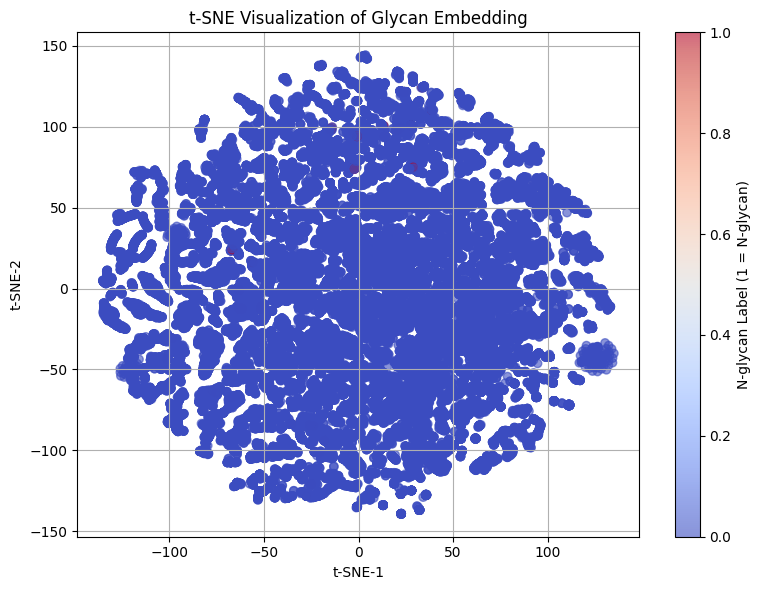

In [ ]:
sil_score_1 = evaluate_embedding_sil_score(emb_matrix_1, N_glycans_df)
nn_purity_1 = evaluate_embedding_nn_purity(emb_matrix_1, N_glycans_df)
#visualize_embedding_tsne(emb_matrix_1, N_glycans_df)

- Silhouette Score: 0.406 --> moderate to strong score. N-glycans are fairly well separated from non-N-glycans in our embedding space.
- NN Purity : 0.108 --> low score. On average, only ~11% of an N-glycan's neighbors are also N-glycans. N-glycans are not grouped together locally. It is possible that either the embedding space is not the best, or the N-glycans are spread across multiple regions, or the N-glycans are outnumbered in the data (imbalance).

This embedding is doing an okay job of separating glycan types overall, but not tightly grouping similar ones together.

In [12]:
#emb_matrix_1.loc[glycan_list['glycan']]

---
- Disease Association
- Protein-Glycan Binding